# Analitycal density and scale height



In [1]:
import sys
print(sys.executable)


import pandas as pd
%matplotlib inline

import matplotlib
print("backend:", matplotlib.get_backend())
import matplotlib.pyplot as plt

import corner
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import os
import argparse
from astropy.io import fits
import numpy as np
import scipy
import glob
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


/home/kandrych/venvs/obriy311/bin/python
backend: module://matplotlib_inline.backend_inline


## Analitical density plots


/fred/oz061/kandrych/tmp/ipykernel_1043180/1063818669.py:9: RuntimeWarning: divide by zero encountered in reciprocal
  sigma_tapered=r**p1*np.exp(-(r/Rc)**(2+p2))


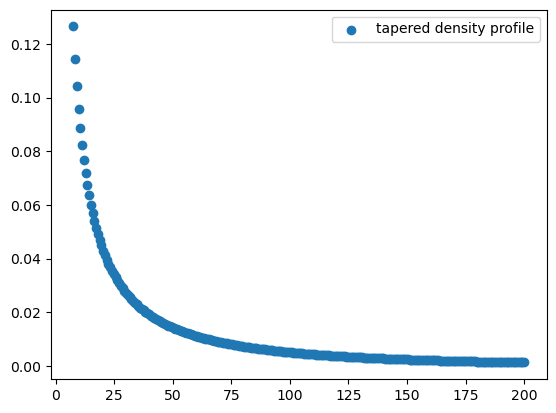

In [ ]:
#density plot for tapered edge
p1=-1
p2=p1 #here with same p1 and p2
Rc=150
rin=7
rout=200

r=np.linspace(0, rout+100, 400)
sigma_tapered=r**p1*np.exp(-(r/Rc)**(2+p2))
mask_in = r < rin
mask_out = r > rout
sigma_tapered[mask_in]=np.nan
sigma_tapered[mask_out]=np.nan
plt.scatter(r, sigma_tapered, label='tapered density profile')
plt.legend()


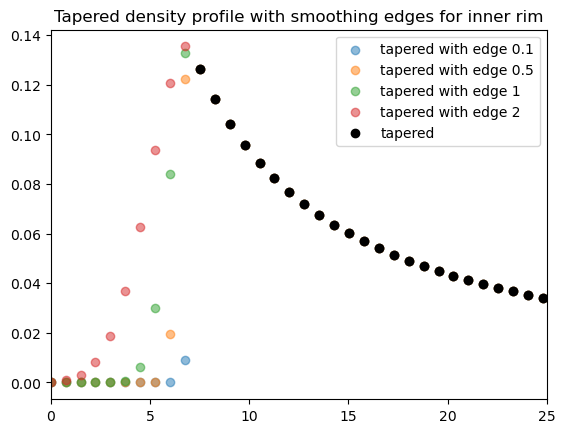

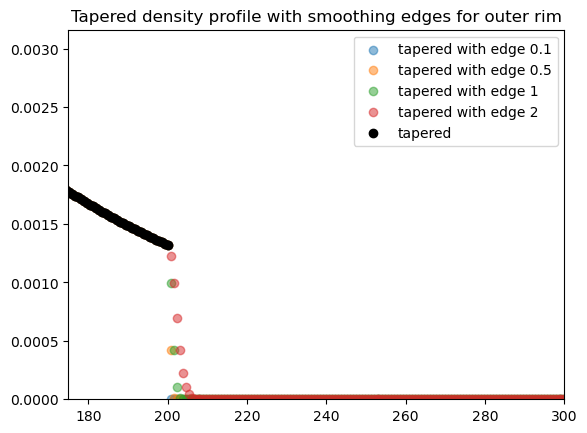

In [ ]:
#With smoothing edge for inner and outer rims

edges=[0.1,0.5,1,2]

sigma_rin = rin**p1 * np.exp(-(rin / Rc)**(2 + p2))
sigma_rout = rout**p1 * np.exp(-(rout / Rc)**(2 + p2))
sigma_tapered_edge={}
mask_in = r < rin
mask_out = r > rout
for edge in edges:
    sigma_tapered_edge[edge] = sigma_tapered.copy()
    sigma_tapered_edge[edge][mask_in] = (
        sigma_rin
        * np.exp(-0.5 * ((r[mask_in] - rin) / edge)**2)
    )

    sigma_tapered_edge[edge][mask_out] = (
        sigma_rout
        * np.exp(-0.5 * ((r[mask_out] - rout) / edge)**2)
    )

    plt.scatter(r, sigma_tapered_edge[edge], label=f'tapered with edge {edge}', alpha=0.5)
    
plt.scatter(r, sigma_tapered, label='tapered', alpha=1, color='black')
plt.title('Tapered density profile with smoothing edges for inner rim')
plt.xlim(0, 25)
plt.legend()
plt.show()
plt.close()



for edge in edges:
    plt.scatter(r, sigma_tapered_edge[edge], label=f'tapered with edge {edge}', alpha=0.5)
plt.scatter(r, sigma_tapered, label='tapered', alpha=1, color='black')
plt.title('Tapered density profile with smoothing edges for outer rim')
plt.xlim(175, 300)
plt.ylim(0, sigma_tapered[175])
plt.legend()
plt.show()
plt.close()




## Analitical scale height profile

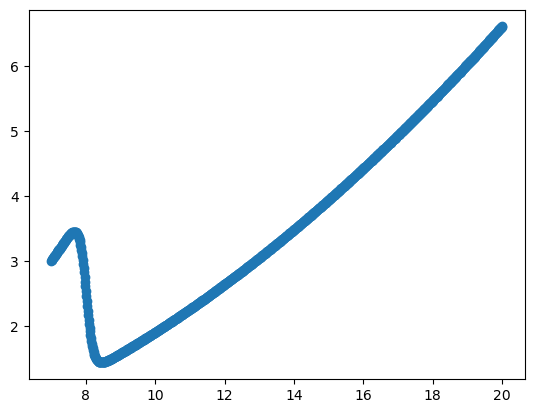

In [ ]:
##puffed inner rim scale height profile

h0=18
r0=100

hrimh0=3

rrim=8
delta_r=0.1
flaring_factor=1.8

r=np.linspace(7, 20, 1000)

h0r=h0*(r/r0)**flaring_factor

h=h0r*(1+(hrimh0 -1)/(np.exp((r-rrim)/delta_r)+1))

plt.scatter(r, h)
#plt.yscale('log')